# Entrenamiento Modelo LightGBM Multi-Horizonte

Este notebook entrena 18 modelos LightGBM independientes (uno por horizonte) para predecir la probabilidad de incumplimiento de créditos.

## Entradas
- `output/datasets/datos_preprocesados.csv` (generado por EDA.ipynb)

## Salidas
- 18 modelos LightGBM entrenados (uno por horizonte)
- Scaler para normalización
- Archivo de configuración con métricas

## Criterio de éxito
- Los modelos se entrenan sin errores
- Se guardan todos los artefactos requeridos
- Se imprime resumen de métricas por horizonte

In [14]:
import os
import sys
import json
import logging
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
import lightgbm as lgb
import mlflow
import mlflow.lightgbm

# Configurar logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)
logger = logging.getLogger(__name__)

## Configuración del notebook

In [15]:
# Configuración de rutas
PATH_INPUT = "output/datasets/datos_preprocesados.csv"
PATH_OUTPUT = "output/modelos_lightgbm"
os.makedirs(PATH_OUTPUT, exist_ok=True)

# Configuración del modelo
VENTANA_LGBM = 6  # Meses de historial para features
MAX_HORIZONTE = 18  # Meses futuros a predecir
TEST_SIZE = 0.3
VAL_SIZE = 0.2

# Hiperparámetros LightGBM
LGBM_PARAMS = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42
}
NUM_BOOST_ROUND = 1000
EARLY_STOPPING_ROUNDS = 50

print(f"Configuración:")
print(f"- Ventana LGBM: {VENTANA_LGBM} meses")
print(f"- Máximo horizonte: {MAX_HORIZONTE} meses")
print(f"- Hiperparámetros: {LGBM_PARAMS}")
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("jupy_entrenamiento_lightgbm")


## Carga de datos

In [16]:
# Cargar datos preprocesados
df = pd.read_csv(PATH_INPUT)
df['mes'] = pd.to_datetime(df['mes'])

print(f"Datos cargados: {len(df):,} registros")
print(f"Columnas: {len(df.columns)}")
print(f"\nDistribución crisis_flag:")
print(df['crisis_flag'].value_counts())
print(f"\nPrimeras filas:")
df.head()

Datos cargados: 20,025 registros
Columnas: 29

Distribución crisis_flag:
crisis_flag
0    17010
1     3015
Name: count, dtype: int64

Primeras filas:


,mes,riesgo,sector,codigo_sucursal,bloque_id,num_creditos,monto_total,monto_promedio,plazo_promedio,tasa_interes_promedio,...,num_clientes_unicos,tasa_judicial,tasa_cierre,tasa_mora_90,desviacion_montos,coef_variacion_montos,creditos_por_cliente,tasa_crecimiento_creditos,tasa_crecimiento_monto,crisis_flag
0,2019-05-01,2,13,1,2_13_1,54,13878000.0,13878000.0,60.0,11.0,...,1,0.0,100.0,0.0,0.00,0.00,54.0,-25.00,671.00,0
1,2019-08-01,2,13,1,2_13_1,60,1080000.0,1080000.0,50.8,10.5,...,2,80.0,100.0,0.0,16135.02,1.49,30.0,650.00,35.00,1
2,2019-11-01,2,13,1,2_13_1,22,8800000.0,8800000.0,28.0,10.5,...,1,0.0,100.0,0.0,0.00,0.00,22.0,-18.52,986.42,0
3,2020-11-01,2,13,1,2_13_1,10,500000.0,500000.0,10.0,10.5,...,1,0.0,100.0,0.0,0.00,0.00,10.0,-16.67,316.67,0
4,2021-04-01,2,13,1,2_13_1,81,2430000.0,2430000.0,84.0,10.5,...,1,0.0,100.0,0.0,0.00,0.00,81.0,237.50,102.50,0


## Preprocesamiento y features

In [17]:
def preprocesar_datos(df):
    """
    Preprocesa los datos para el modelado LightGBM.
    """
    df_features = df.copy()
    
    # Asegurar que mes sea datetime
    df_features['mes'] = pd.to_datetime(df_features['mes'])
    
    # Columnas numéricas para el modelo (todas las disponibles)
    features_numericas = [
        'num_creditos', 'monto_total', 'monto_promedio', 'plazo_promedio',
        'tasa_interes_promedio', 'saldo_promedio', 'total_costo_judicial',
        'total_gestion_cobro', 'total_notificaciones', 'tot_dias_mora_promedio',
        'tot_num_moras_promedio', 'mora_promedio', 'creditos_judiciales',
        'creditos_cerrados', 'tasa_judicial', 'tasa_cierre',
        'tasa_mora_90', 'creditos_por_cliente', 'coef_variacion_montos',
        'tasa_crecimiento_creditos', 'tasa_crecimiento_monto',
    ]
    
    # Verificar que todas las columnas existan
    features_existentes = [f for f in features_numericas if f in df_features.columns]
    
    # Ordenar por bloque y mes
    df_features = df_features.sort_values(['bloque_id', 'mes'])
    
    logger.info(f"Features seleccionadas: {len(features_existentes)}")
    logger.info(f"Bloques únicos: {df_features['bloque_id'].nunique()}")
    
    return df_features, features_existentes

In [18]:
df_features, features_numericas = preprocesar_datos(df)
print(f"\nFeatures para el modelo ({len(features_numericas)}):")
print(features_numericas)

2026-07-10 15:14:22,119 - INFO - Features seleccionadas: 21
2026-07-10 15:14:22,120 - INFO - Bloques únicos: 950



Features para el modelo (21):
['num_creditos', 'monto_total', 'monto_promedio', 'plazo_promedio', 'tasa_interes_promedio', 'saldo_promedio', 'total_costo_judicial', 'total_gestion_cobro', 'total_notificaciones', 'tot_dias_mora_promedio', 'tot_num_moras_promedio', 'mora_promedio', 'creditos_judiciales', 'creditos_cerrados', 'tasa_judicial', 'tasa_cierre', 'tasa_mora_90', 'creditos_por_cliente', 'coef_variacion_montos', 'tasa_crecimiento_creditos', 'tasa_crecimiento_monto']


## Creación de secuencias temporales

In [19]:
def crear_secuencias_lgbm(df, bloque_id, features, ventana, max_horizonte):
    """
    Genera secuencias temporales para LightGBM.
    Para cada mes, crea features con el historial de los últimos 'ventana' meses.
    """
    df_bloque = df[df['bloque_id'] == bloque_id].sort_values('mes')
    
    if len(df_bloque) < ventana + max_horizonte:
        return None, None, None
    
    X_sequences = []
    y_sequences = []
    meses_target = []
    
    for i in range(len(df_bloque) - ventana - max_horizonte + 1):
        # Features: estadísticas del historial de ventana meses
        historial = df_bloque[features].iloc[i:i+ventana]
        
        # Crear features estadísticas
        features_seq = []
        for col in features:
            valores = historial[col].values
            features_seq.extend([
                np.mean(valores),
                np.std(valores),
                np.min(valores),
                np.max(valores),
                np.median(valores),
                valores[-1],  # Último valor
                valores[-1] - valores[0],  # Tendencia
            ])
        
        # Target: crisis_flag en cada horizonte
        y_seq = []
        for h in range(1, max_horizonte + 1):
            if i + ventana + h - 1 < len(df_bloque):
                y_val = df_bloque['crisis_flag'].iloc[i + ventana + h - 1]
                y_seq.append(y_val)
            else:
                y_seq.append(0)
        
        X_sequences.append(features_seq)
        y_sequences.append(y_seq)
        meses_target.append(df_bloque['mes'].iloc[i + ventana - 1])
    
    return np.array(X_sequences), np.array(y_sequences), meses_target

In [20]:
# Generar secuencias para todos los bloques
X_all = []
y_all = []
fechas_all = []
bloques_validos = []

for bloque in df_features['bloque_id'].unique():
    X_seq, y_seq, fechas_seq = crear_secuencias_lgbm(
        df_features, bloque, features_numericas,
        VENTANA_LGBM, MAX_HORIZONTE
    )
    if X_seq is not None and len(X_seq) > 0:
        X_all.extend(X_seq)
        y_all.extend(y_seq)
        fechas_all.extend(fechas_seq)
        bloques_validos.append(bloque)

X_lgbm = np.array(X_all)
y_lgbm = np.array(y_all)
fechas_lgbm = np.array(fechas_all)

if X_lgbm.shape[0] == 0:
    raise ValueError(
        "No se generaron secuencias para entrenar (X_lgbm vacio). "
        "Reduce VENTANA_LGBM y/o MAX_HORIZONTE, o valida que haya mas meses por bloque."
    )

# Crear nombres de features estadisticas
feature_names = []
for col in features_numericas:
    for stat in ['mean', 'std', 'min', 'max', 'median', 'last', 'trend']:
        feature_names.append(f"{col}_{stat}")

print(f"Secuencias generadas:")
print(f"- X shape: {X_lgbm.shape}")
print(f"- y shape: {y_lgbm.shape}")
print(f"- Fechas: {fechas_lgbm.min()} a {fechas_lgbm.max()}")
print(f"- Bloques validos: {len(bloques_validos)}")
print(f"- Features: {len(feature_names)}")
print(f"- Horizontes: {MAX_HORIZONTE}")

Secuencias generadas:
- X shape: (5736, 147)
- y shape: (5736, 18)
- Fechas: 2019-06-01 00:00:00 a 2021-06-01 00:00:00
- Bloques validos: 419
- Features: 147
- Horizontes: 18


## División de datos

In [21]:
# Ordenar por mes_prediccion para split temporal (sin data leakage)
sort_idx = np.argsort(fechas_lgbm)
X_lgbm = X_lgbm[sort_idx]
y_lgbm = y_lgbm[sort_idx]
fechas_lgbm = fechas_lgbm[sort_idx]
print(f'Fechas de prediccion: {fechas_lgbm.min()} a {fechas_lgbm.max()}')

if X_lgbm.shape[0] < 2:
    raise ValueError(
        f"Muestras insuficientes: n_samples={X_lgbm.shape[0]}. "
        "Revisa la celda de secuencias y ajusta ventana/horizonte."
    )

# Split temporal 70/30
split_idx = int(len(X_lgbm) * 0.7)
X_train, X_test = X_lgbm[:split_idx], X_lgbm[split_idx:]
y_train, y_test = y_lgbm[:split_idx], y_lgbm[split_idx:]

# Split train/val 80/20
split_val_idx = int(len(X_train) * 0.8)
X_val = X_train[split_val_idx:]
y_val = y_train[split_val_idx:]
X_train = X_train[:split_val_idx]
y_train = y_train[:split_val_idx]

print(f"Division de datos:")
print(f"- Train: {X_train.shape[0]:,} muestras")
print(f"- Validation: {X_val.shape[0]:,} muestras")
print(f"- Test: {X_test.shape[0]:,} muestras")
print(f"- Features: {X_train.shape[1]}")
print(f"- Horizontes: {MAX_HORIZONTE}")

Fechas de prediccion: 2019-06-01 00:00:00 a 2021-06-01 00:00:00
Division de datos:
- Train: 3,212 muestras
- Validation: 803 muestras
- Test: 1,721 muestras
- Features: 147
- Horizontes: 18


## Entrenamiento de modelos LightGBM

In [22]:
# Entrenar un modelo por horizonte
mlflow.start_run(run_name=f"lgbm_{datetime.now().strftime("%Y%m%d_%H%M%S")}")

modelos = []
metricas_por_horizonte = []

print("=" * 60)
print("ENTRENAMIENTO DE MODELOS LIGHTGBM")
print("=" * 60)

for h in range(MAX_HORIZONTE):
    print(f"\n--- Horizonte {h+1} meses ---")
    
    # Targets para este horizonte
    y_train_h = y_train[:, h]
    y_val_h = y_val[:, h]
    y_test_h = y_test[:, h]
    
    # Calcular peso para desbalanceo de clases
    n_pos = np.sum(y_train_h == 1)
    n_neg = np.sum(y_train_h == 0)
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1
    
    # Crear datasets LightGBM
    train_data = lgb.Dataset(X_train, label=y_train_h, feature_name=feature_names)
    val_data = lgb.Dataset(X_val, label=y_val_h, feature_name=feature_names, reference=train_data)
    
    # Parámetros para este horizonte
    params = LGBM_PARAMS.copy()
    params['scale_pos_weight'] = scale_pos_weight
    
    # Entrenar con early stopping
    modelo = lgb.train(
        params,
        train_data,
        num_boost_round=NUM_BOOST_ROUND,
        valid_sets=[val_data],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS),
            lgb.log_evaluation(100)
        ]
    )
    
    # Evaluar en test
    y_pred_proba = modelo.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    acc = accuracy_score(y_test_h, y_pred)
    prec = precision_score(y_test_h, y_pred, zero_division=0)
    rec = recall_score(y_test_h, y_pred, zero_division=0)
    
    auc = 0.5
    if len(np.unique(y_test_h)) > 1:
        try:
            auc = roc_auc_score(y_test_h, y_pred_proba)
        except:
            pass
    
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  AUC-ROC: {auc:.4f}")
    
    # Guardar modelo y métricas
    modelos.append(modelo)
    metricas_por_horizonte.append({
        'horizonte': h + 1,
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'auc_roc': float(auc),
        'num_iteraciones': modelo.num_trees(),
        'scale_pos_weight': float(scale_pos_weight)
    })
    
    # Guardar modelo individual
    modelo_path = os.path.join(PATH_OUTPUT, f'modelo_lgbm_h{h+1}.txt')
    modelo.save_model(modelo_path)
    # MLflow: log modelo e metricas de este horizonte
    mlflow.lightgbm.log_model(modelo, f"modelo_h{h+1}")
    mlflow.log_metric(f"h{h+1}_accuracy", acc)
    mlflow.log_metric(f"h{h+1}_precision", prec)
    mlflow.log_metric(f"h{h+1}_recall", rec)
    mlflow.log_metric(f"h{h+1}_auc_roc", auc)
    mlflow.log_metric(f"h{h+1}_iteraciones", modelo.num_trees())

mlflow.end_run()


## Evaluación global

In [23]:
# Resumen de métricas por horizonte
df_metricas = pd.DataFrame(metricas_por_horizonte)

print("\n" + "=" * 60)
print("RESUMEN DE MÉTRICAS POR HORIENTE")
print("=" * 60)
print(df_metricas.to_string(index=False))

# Métricas promedio
print("\n" + "=" * 60)
print("MÉTRICAS PROMEDIO")
print("=" * 60)
print(f"Accuracy promedio: {df_metricas['accuracy'].mean():.4f}")
print(f"Precision promedio: {df_metricas['precision'].mean():.4f}")
print(f"Recall promedio: {df_metricas['recall'].mean():.4f}")
print(f"AUC-ROC promedio: {df_metricas['auc_roc'].mean():.4f}")


RESUMEN DE MÉTRICAS POR HORIENTE
 horizonte  accuracy  precision   recall  auc_roc  num_iteraciones  scale_pos_weight
         1  0.937246   0.694215 0.541935 0.874428               67          8.733333
         2  0.944218   0.841584 0.515152 0.889892               48          8.022472
         3  0.941894   0.836538 0.511765 0.869136               36          7.214834
         4  0.930273   0.683761 0.490798 0.854344               97          6.853301
         5  0.933178   0.708333 0.515152 0.852688               60          6.350114
         6  0.927368   0.631579 0.525000 0.837946               31          5.922414
         7  0.930273   0.669643 0.474684 0.822022               40          5.622680
         8  0.913422   0.529412 0.512658 0.840812               98          5.424000
         9  0.929692   0.675926 0.459119 0.790198               45          5.188825
        10  0.918652   0.513761 0.391608 0.767416               44          5.060377
        11  0.894829   0.380645

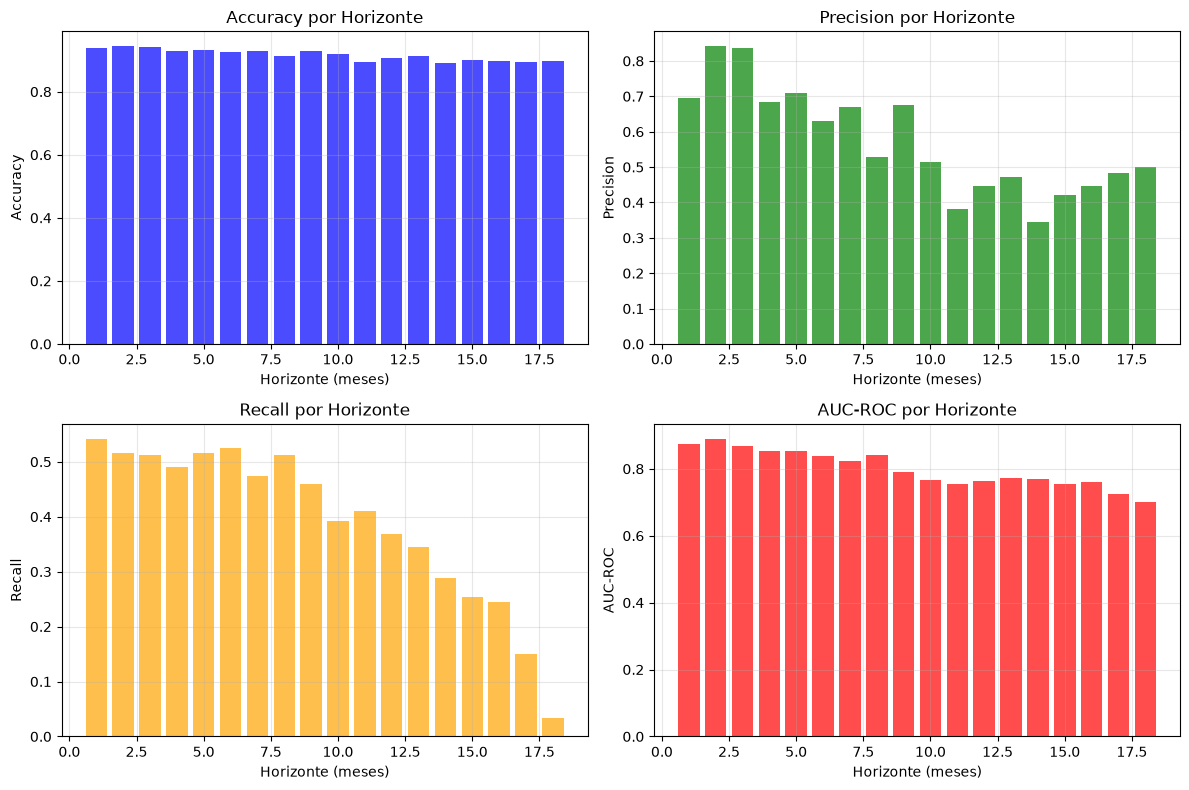

In [24]:
# Gráfica de métricas por horizonte
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Accuracy
axes[0, 0].bar(df_metricas['horizonte'], df_metricas['accuracy'], color='blue', alpha=0.7)
axes[0, 0].set_title('Accuracy por Horizonte')
axes[0, 0].set_xlabel('Horizonte (meses)')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True, alpha=0.3)

# Precision
axes[0, 1].bar(df_metricas['horizonte'], df_metricas['precision'], color='green', alpha=0.7)
axes[0, 1].set_title('Precision por Horizonte')
axes[0, 1].set_xlabel('Horizonte (meses)')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].grid(True, alpha=0.3)

# Recall
axes[1, 0].bar(df_metricas['horizonte'], df_metricas['recall'], color='orange', alpha=0.7)
axes[1, 0].set_title('Recall por Horizonte')
axes[1, 0].set_xlabel('Horizonte (meses)')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].grid(True, alpha=0.3)

# AUC-ROC
axes[1, 1].bar(df_metricas['horizonte'], df_metricas['auc_roc'], color='red', alpha=0.7)
axes[1, 1].set_title('AUC-ROC por Horizonte')
axes[1, 1].set_xlabel('Horizonte (meses)')
axes[1, 1].set_ylabel('AUC-ROC')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'metricas_por_horizonte.png'), dpi=150, bbox_inches='tight')
plt.show()

## Importancia de features


Top 20 features más importantes:
                         feature  importancia
              num_creditos_trend    37.500000
 tasa_crecimiento_creditos_trend    36.888889
   tasa_crecimiento_monto_median    36.277778
   tasa_crecimiento_creditos_min    35.666667
tasa_crecimiento_creditos_median    34.833333
      tasa_crecimiento_monto_min    33.833333
              plazo_promedio_std    33.777778
      creditos_por_cliente_trend    32.611111
        creditos_por_cliente_std    32.333333
     coef_variacion_montos_trend    31.944444
               monto_total_trend    31.222222
     tasa_crecimiento_monto_last    29.944444
    tasa_crecimiento_monto_trend    29.722222
            plazo_promedio_trend    29.388889
  tasa_crecimiento_creditos_last    28.888889
             plazo_promedio_last    28.111111
  tasa_crecimiento_creditos_mean    27.722222
     tasa_crecimiento_monto_mean    27.055556
           plazo_promedio_median    26.888889
     creditos_por_cliente_median    26.500000


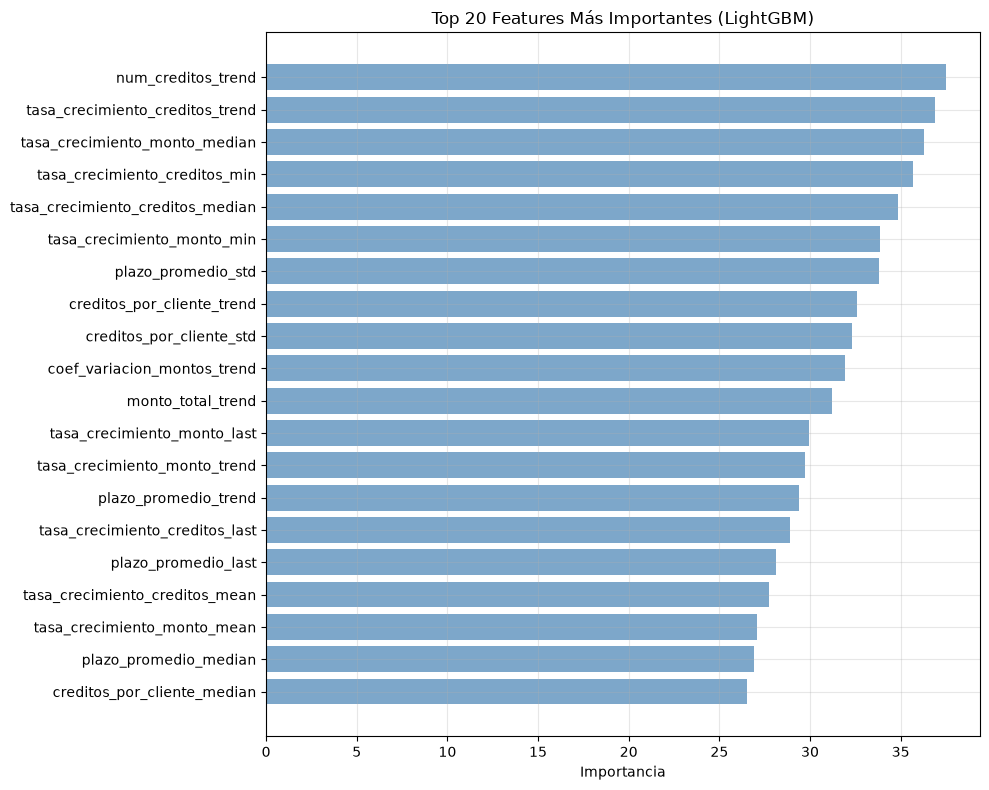

In [25]:
# Importancia de features (promedio de todos los horizontes)
importancia_total = np.zeros(len(feature_names))

for modelo in modelos:
    importancia_total += modelo.feature_importance()

importancia_promedio = importancia_total / len(modelos)

# Crear DataFrame de importancia
df_importancia = pd.DataFrame({
    'feature': feature_names,
    'importancia': importancia_promedio
}).sort_values('importancia', ascending=False)

# Top 20 features
print("\nTop 20 features más importantes:")
print(df_importancia.head(20).to_string(index=False))

# Gráfica
plt.figure(figsize=(10, 8))
top_20 = df_importancia.head(20)
plt.barh(range(len(top_20)), top_20['importancia'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Importancia')
plt.title('Top 20 Features Más Importantes (LightGBM)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'importancia_features.png'), dpi=150, bbox_inches='tight')
plt.show()

## Guardado de artefactos

In [26]:
# Guardar scaler (aunque no se usa para features estadísticas, se guarda por consistencia)
scaler = MinMaxScaler()
scaler.fit(X_lgbm)
scaler_path = os.path.join(PATH_OUTPUT, 'scaler_lgbm.pkl')
joblib.dump(scaler, scaler_path)
logger.info(f"Scaler guardado en: {scaler_path}")

# Guardar configuración y métricas
config = {
    'ventana_lgbm': VENTANA_LGBM,
    'max_horizonte': MAX_HORIZONTE,
    'features_numericas': features_numericas,
    'feature_names': feature_names,
    'bloques_validos': bloques_validos,
    'hiperparametros': LGBM_PARAMS,
    'num_boost_round': NUM_BOOST_ROUND,
    'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    'metricas_por_horizonte': metricas_por_horizonte,
    'metricas_promedio': {
        'accuracy': float(df_metricas['accuracy'].mean()),
        'precision': float(df_metricas['precision'].mean()),
        'recall': float(df_metricas['recall'].mean()),
        'auc_roc': float(df_metricas['auc_roc'].mean()),
    },
    'fecha_entrenamiento': datetime.now().isoformat(),
    'num_muestras_train': int(X_train.shape[0]),
    'num_muestras_val': int(X_val.shape[0]),
    'num_muestras_test': int(X_test.shape[0]),
}

config_path = os.path.join(PATH_OUTPUT, 'config_lgbm_18m.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2, default=str)
logger.info(f"Configuración guardada en: {config_path}")

# Guardar métricas como CSV
metricas_path = os.path.join(PATH_OUTPUT, 'metricas_lightgbm.csv')
df_metricas.to_csv(metricas_path, index=False)
logger.info(f"Métricas guardadas en: {metricas_path}")

print("\n" + "=" * 60)
print("ARTEFACTOS GUARDADOS")
print("=" * 60)
print(f"1. Modelos: {PATH_OUTPUT}/modelo_lgbm_h*.txt (18 archivos)")
print(f"2. Scaler: {scaler_path}")
print(f"3. Configuración: {config_path}")
print(f"4. Métricas: {metricas_path}")
print(f"5. Gráficas: {PATH_OUTPUT}/metricas_por_horizonte.png")
print(f"6. Gráficas: {PATH_OUTPUT}/importancia_features.png")

2026-07-10 15:14:46,336 - INFO - Scaler guardado en: output/modelos_lightgbm/scaler_lgbm.pkl
2026-07-10 15:14:46,338 - INFO - Configuración guardada en: output/modelos_lightgbm/config_lgbm_18m.json
2026-07-10 15:14:46,342 - INFO - Métricas guardadas en: output/modelos_lightgbm/metricas_lightgbm.csv



ARTEFACTOS GUARDADOS
1. Modelos: output/modelos_lightgbm/modelo_lgbm_h*.txt (18 archivos)
2. Scaler: output/modelos_lightgbm/scaler_lgbm.pkl
3. Configuración: output/modelos_lightgbm/config_lgbm_18m.json
4. Métricas: output/modelos_lightgbm/metricas_lightgbm.csv
5. Gráficas: output/modelos_lightgbm/metricas_por_horizonte.png
6. Gráficas: output/modelos_lightgbm/importancia_features.png


## Resumen de ejecución

- Fecha de ejecución:
- Bloques válidos:
- Muestras de entrenamiento:
- Muestras de validación:
- Muestras de prueba:
- Métricas promedio:
  - Accuracy:
  - Precision:
  - Recall:
  - AUC-ROC:
- Artefactos generados:
  - output/modelos_lightgbm/modelo_lgbm_h*.txt (18 modelos)
  - output/modelos_lightgbm/scaler_lgbm.pkl
  - output/modelos_lightgbm/config_lgbm_18m.json
  - output/modelos_lightgbm/metricas_lightgbm.csv
  - output/modelos_lightgbm/metricas_por_horizonte.png
  - output/modelos_lightgbm/importancia_features.png

![icon](../../DocumentosBase/yachayCuadrado.jpg)<br/>***<omar.velez@yachaytech.edu.ec>***<br/>*julio 2026*